In [1]:
# Goal:
# Run a more robust pole vegetation risk analysis using only poles inside all three model footprints.
#
# Robust risk rule:
# risk if:
#   buffer_p95_m >= pole_height_m
#   OR
#   buffer_above_pole_pct >= 20


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import rasterio
from rasterio.transform import rowcol
from rasterio.warp import transform


In [4]:
csv_path = Path("/content/drive/MyDrive/electric-pole-analysis/outputs/pole_filtering/poles_inside_all_three_models.csv")

chmv1_path = Path("/content/drive/MyDrive/electric-pole-analysis/outputs/chmv1_rgb3_alpha_nodata255_res060_chm.tif")
chmv2_min_path = Path("/content/drive/MyDrive/electric-pole-analysis/outputs/chmv2_minimal_tile512_ov64.tif")
chmv2_std_path = Path("/content/drive/MyDrive/electric-pole-analysis/outputs/chmv2_standardized_tile512_ov64.tif")

for p in [csv_path, chmv1_path, chmv2_min_path, chmv2_std_path]:
    print(p.name, "->", p.exists())


poles_inside_all_three_models.csv -> True
chmv1_rgb3_alpha_nodata255_res060_chm.tif -> True
chmv2_minimal_tile512_ov64.tif -> True
chmv2_standardized_tile512_ov64.tif -> True


In [5]:
RADIUS_M = 2.0
POLE_HEIGHT_FT = 30.0
POLE_HEIGHT_M = POLE_HEIGHT_FT * 0.3048
ABOVE_POLE_THRESHOLD_PCT = 20.0

print("Radius (m):", RADIUS_M)
print("Pole height (ft):", POLE_HEIGHT_FT)
print("Pole height (m):", POLE_HEIGHT_M)
print("Above-pole threshold (%):", ABOVE_POLE_THRESHOLD_PCT)


Radius (m): 2.0
Pole height (ft): 30.0
Pole height (m): 9.144
Above-pole threshold (%): 20.0


In [6]:
df = pd.read_csv(csv_path)
print("Rows:", len(df))
print("Columns:", list(df.columns))
df.head()


Rows: 242
Columns: ['pole_id', 'image_name', 'veg_id', 'veg_name', 'comment', 'labeled_at', 'objectid', 'elt_id', 'pole_lat', 'pole_lng', 'sv_status', 'pano_id', 'sv_date', 'sv_lat', 'sv_lng', 'copyright', 'manual_risk', 'pole_height_ft', 'pole_height_m', 'x_utm', 'y_utm', 'chmv1_center_row', 'chmv1_center_col', 'chmv1_buffer_valid_count', 'chmv1_buffer_max_m', 'chmv1_buffer_mean_m', 'chmv1_buffer_p95_m', 'chmv1_buffer_above_pole_count', 'chmv1_buffer_above_pole_pct', 'chmv1_buffer_risk', 'chmv2_min_center_row', 'chmv2_min_center_col', 'chmv2_min_buffer_valid_count', 'chmv2_min_buffer_max_m', 'chmv2_min_buffer_mean_m', 'chmv2_min_buffer_p95_m', 'chmv2_min_buffer_above_pole_count', 'chmv2_min_buffer_above_pole_pct', 'chmv2_min_buffer_risk', 'chmv2_std_center_row', 'chmv2_std_center_col', 'chmv2_std_buffer_valid_count', 'chmv2_std_buffer_max_m', 'chmv2_std_buffer_mean_m', 'chmv2_std_buffer_p95_m', 'chmv2_std_buffer_above_pole_count', 'chmv2_std_buffer_above_pole_pct', 'chmv2_std_buffer_r

,pole_id,image_name,veg_id,veg_name,comment,labeled_at,objectid,elt_id,pole_lat,pole_lng,...,inside_chmv1,inside_chmv2_min,inside_chmv2_std,row_chmv1,col_chmv1,row_chmv2_min,col_chmv2_min,row_chmv2_std,col_chmv2_std,inside_all_three
0,38.972777_-77.063682,38.972777_-77.063682.jpg,1,watch,NaN,2026-02-24T11:08:58,484,8138,38.972777,-77.063682,...,True,True,True,2284,432,2741,519,2284,432,True
1,38.972779_-77.064024,38.972779_-77.064024.jpg,0,clear,NaN,2026-02-24T11:09:14,16041,8296,38.972779,-77.064024,...,True,True,True,2283,383,2740,459,2283,383,True
2,38.972783_-77.056265,38.972783_-77.056265.jpg,0,clear,NaN,2026-02-24T11:09:25,79372,2723,38.972783,-77.056265,...,True,True,True,2308,1503,2769,1804,2308,1503,True
3,38.972783_-77.060129,38.972783_-77.060129.jpg,0,clear,NaN,2026-02-24T11:09:36,57192,7786,38.972783,-77.060129,...,True,True,True,2295,945,2754,1134,2295,945,True
4,38.972787_-77.054236,38.972787_-77.054236.jpg,3,critical,NaN,2026-02-24T11:09:47,35110,2576,38.972787,-77.054236,...,True,True,True,2313,1796,2776,2155,2313,1796,True


In [7]:
def classify_manual_risk(row):
    veg_id = row["veg_id"]
    veg_name = str(row["veg_name"]).strip().lower()

    if veg_id == 0 or veg_name in {"clear", "safe"}:
        return "safe"
    if veg_id in {1, 2, 3} or veg_name in {"high", "watch", "critical", "risk"}:
        return "risk"
    return "unknown"

df["manual_risk"] = df.apply(classify_manual_risk, axis=1)
df["pole_height_m"] = POLE_HEIGHT_M

df[["pole_id", "veg_id", "veg_name", "manual_risk", "pole_height_m"]].head()


,pole_id,veg_id,veg_name,manual_risk,pole_height_m
0,38.972777_-77.063682,1,watch,risk,9.144
1,38.972779_-77.064024,0,clear,safe,9.144
2,38.972783_-77.056265,0,clear,safe,9.144
3,38.972783_-77.060129,0,clear,safe,9.144
4,38.972787_-77.054236,3,critical,risk,9.144


In [8]:
with rasterio.open(chmv1_path) as src:
    chmv1 = src.read(1)
    chmv1_transform = src.transform
    chmv1_crs = src.crs

with rasterio.open(chmv2_min_path) as src:
    chmv2_min = src.read(1)
    chmv2_min_transform = src.transform
    chmv2_min_crs = src.crs

with rasterio.open(chmv2_std_path) as src:
    chmv2_std = src.read(1)
    chmv2_std_transform = src.transform
    chmv2_std_crs = src.crs

print("CHMv1 shape:", chmv1.shape)
print("CHMv2 minimal shape:", chmv2_min.shape)
print("CHMv2 standardized shape:", chmv2_std.shape)


CHMv1 shape: (2330, 2194)
CHMv2 minimal shape: (2796, 2632)
CHMv2 standardized shape: (2330, 2194)


In [9]:
xs, ys = transform(
    "EPSG:4326",
    chmv1_crs,
    df["pole_lng"].tolist(),
    df["pole_lat"].tolist(),
)

df["x_utm"] = xs
df["y_utm"] = ys

df[["pole_id", "pole_lat", "pole_lng", "x_utm", "y_utm"]].head()


,pole_id,pole_lat,pole_lng,x_utm,y_utm
0,38.972777_-77.063682,38.972777,-77.063682,321225.547714,4.315781e+06
1,38.972779_-77.064024,38.972779,-77.064024,321195.908434,4.315782e+06
2,38.972783_-77.056265,38.972783,-77.056265,321868.114389,4.315767e+06
3,38.972783_-77.060129,38.972783,-77.060129,321533.406872,4.315775e+06
4,38.972787_-77.054236,38.972787,-77.054236,322043.956351,4.315764e+06


In [10]:
def extract_buffer_stats(arr, transform_obj, x, y, radius_m, pole_height_m):
    row, col = rowcol(transform_obj, x, y)

    if row < 0 or col < 0 or row >= arr.shape[0] or col >= arr.shape[1]:
        return {
            "buffer_valid_count": 0,
            "buffer_max_m": np.nan,
            "buffer_mean_m": np.nan,
            "buffer_p95_m": np.nan,
            "buffer_above_pole_count": 0,
            "buffer_above_pole_pct": np.nan,
        }

    pixel_size_x = abs(transform_obj.a)
    pixel_size_y = abs(transform_obj.e)

    row_radius = int(np.ceil(radius_m / pixel_size_y))
    col_radius = int(np.ceil(radius_m / pixel_size_x))

    r0 = max(0, row - row_radius)
    r1 = min(arr.shape[0], row + row_radius + 1)
    c0 = max(0, col - col_radius)
    c1 = min(arr.shape[1], col + col_radius + 1)

    window = arr[r0:r1, c0:c1]

    rows = np.arange(r0, r1)
    cols = np.arange(c0, c1)
    rr, cc = np.meshgrid(rows, cols, indexing="ij")

    xs = transform_obj.c + (cc + 0.5) * transform_obj.a
    ys = transform_obj.f + (rr + 0.5) * transform_obj.e

    dist = np.sqrt((xs - x) ** 2 + (ys - y) ** 2)
    inside = dist <= radius_m
    valid = inside & np.isfinite(window)

    if not valid.any():
        return {
            "buffer_valid_count": 0,
            "buffer_max_m": np.nan,
            "buffer_mean_m": np.nan,
            "buffer_p95_m": np.nan,
            "buffer_above_pole_count": 0,
            "buffer_above_pole_pct": np.nan,
        }

    vals = window[valid]
    above_count = int(np.sum(vals >= pole_height_m))
    total_valid = int(vals.size)

    return {
        "buffer_valid_count": total_valid,
        "buffer_max_m": float(np.nanmax(vals)),
        "buffer_mean_m": float(np.nanmean(vals)),
        "buffer_p95_m": float(np.nanpercentile(vals, 95)),
        "buffer_above_pole_count": above_count,
        "buffer_above_pole_pct": 100 * above_count / total_valid,
    }


In [11]:
res1 = [extract_buffer_stats(chmv1, chmv1_transform, x, y, RADIUS_M, POLE_HEIGHT_M) for x, y in zip(df["x_utm"], df["y_utm"])]
res2 = [extract_buffer_stats(chmv2_min, chmv2_min_transform, x, y, RADIUS_M, POLE_HEIGHT_M) for x, y in zip(df["x_utm"], df["y_utm"])]
res3 = [extract_buffer_stats(chmv2_std, chmv2_std_transform, x, y, RADIUS_M, POLE_HEIGHT_M) for x, y in zip(df["x_utm"], df["y_utm"])]

for prefix, results in [
    ("chmv1", res1),
    ("chmv2_min", res2),
    ("chmv2_std", res3),
]:
    tmp = pd.DataFrame(results)
    tmp.columns = [f"{prefix}_{c}" for c in tmp.columns]
    df = pd.concat([df.reset_index(drop=True), tmp.reset_index(drop=True)], axis=1)

df.head()


,pole_id,image_name,veg_id,veg_name,comment,labeled_at,objectid,elt_id,pole_lat,pole_lng,...,chmv2_min_buffer_mean_m,chmv2_min_buffer_p95_m,chmv2_min_buffer_above_pole_count,chmv2_min_buffer_above_pole_pct,chmv2_std_buffer_valid_count,chmv2_std_buffer_max_m,chmv2_std_buffer_mean_m,chmv2_std_buffer_p95_m,chmv2_std_buffer_above_pole_count,chmv2_std_buffer_above_pole_pct
0,38.972777_-77.063682,38.972777_-77.063682.jpg,1,watch,NaN,2026-02-24T11:08:58,484,8138,38.972777,-77.063682,...,0.636455,2.482185,0,0.0,34,1.366594,0.679525,1.267413,0,0.0
1,38.972779_-77.064024,38.972779_-77.064024.jpg,0,clear,NaN,2026-02-24T11:09:14,16041,8296,38.972779,-77.064024,...,0.492317,1.845706,0,0.0,35,0.117898,0.046279,0.098162,0,0.0
2,38.972783_-77.056265,38.972783_-77.056265.jpg,0,clear,NaN,2026-02-24T11:09:25,79372,2723,38.972783,-77.056265,...,0.042247,0.081706,0,0.0,35,0.251033,0.072880,0.143379,0,0.0
3,38.972783_-77.060129,38.972783_-77.060129.jpg,0,clear,NaN,2026-02-24T11:09:36,57192,7786,38.972783,-77.060129,...,0.054248,0.139039,0,0.0,35,0.078919,0.040960,0.066678,0,0.0
4,38.972787_-77.054236,38.972787_-77.054236.jpg,3,critical,NaN,2026-02-24T11:09:47,35110,2576,38.972787,-77.054236,...,18.342041,19.624313,50,100.0,35,17.370743,15.397110,17.095921,35,100.0


In [12]:
def robust_radius_risk(buffer_p95_m, buffer_above_pole_pct, pole_height_m):
    if pd.isna(buffer_p95_m) or pd.isna(buffer_above_pole_pct):
        return "no_data"

    if (buffer_p95_m >= pole_height_m) or (buffer_above_pole_pct >= ABOVE_POLE_THRESHOLD_PCT):
        return "risk"

    return "safe"

print("Robust rule:")
print(f"risk if buffer_p95_m >= pole_height_m OR buffer_above_pole_pct >= {ABOVE_POLE_THRESHOLD_PCT}%")


Robust rule:
risk if buffer_p95_m >= pole_height_m OR buffer_above_pole_pct >= 20.0%


In [15]:
dup_cols = df.columns[df.columns.duplicated()].tolist()
print("Duplicate columns:", dup_cols)


Duplicate columns: ['chmv1_buffer_valid_count', 'chmv1_buffer_max_m', 'chmv1_buffer_mean_m', 'chmv1_buffer_p95_m', 'chmv1_buffer_above_pole_count', 'chmv1_buffer_above_pole_pct', 'chmv2_min_buffer_valid_count', 'chmv2_min_buffer_max_m', 'chmv2_min_buffer_mean_m', 'chmv2_min_buffer_p95_m', 'chmv2_min_buffer_above_pole_count', 'chmv2_min_buffer_above_pole_pct', 'chmv2_std_buffer_valid_count', 'chmv2_std_buffer_max_m', 'chmv2_std_buffer_mean_m', 'chmv2_std_buffer_p95_m', 'chmv2_std_buffer_above_pole_count', 'chmv2_std_buffer_above_pole_pct']


In [16]:
df = df.loc[:, ~df.columns.duplicated()].copy()
print("Shape after removing duplicate columns:", df.shape)


Shape after removing duplicate columns: (242, 58)


In [17]:
df["chmv1_risk_robust"] = df.apply(
    lambda r: robust_radius_risk(r["chmv1_buffer_p95_m"], r["chmv1_buffer_above_pole_pct"], r["pole_height_m"]),
    axis=1
)

df["chmv2_min_risk_robust"] = df.apply(
    lambda r: robust_radius_risk(r["chmv2_min_buffer_p95_m"], r["chmv2_min_buffer_above_pole_pct"], r["pole_height_m"]),
    axis=1
)

df["chmv2_std_risk_robust"] = df.apply(
    lambda r: robust_radius_risk(r["chmv2_std_buffer_p95_m"], r["chmv2_std_buffer_above_pole_pct"], r["pole_height_m"]),
    axis=1
)


In [18]:
df[[
    "pole_id",
    "manual_risk",
    "chmv1_buffer_p95_m",
    "chmv1_buffer_above_pole_pct",
    "chmv1_risk_robust",
    "chmv2_min_buffer_p95_m",
    "chmv2_min_buffer_above_pole_pct",
    "chmv2_min_risk_robust",
    "chmv2_std_buffer_p95_m",
    "chmv2_std_buffer_above_pole_pct",
    "chmv2_std_risk_robust",
]].head(10)


,pole_id,manual_risk,chmv1_buffer_p95_m,chmv1_buffer_above_pole_pct,chmv1_risk_robust,chmv2_min_buffer_p95_m,chmv2_min_buffer_above_pole_pct,chmv2_min_risk_robust,chmv2_std_buffer_p95_m,chmv2_std_buffer_above_pole_pct,chmv2_std_risk_robust
0,38.972777_-77.063682,risk,0.068020,0.000000,safe,2.482185,0.000000,safe,1.267413,0.000000,safe
1,38.972779_-77.064024,safe,0.068676,0.000000,safe,1.845706,0.000000,safe,0.098162,0.000000,safe
2,38.972783_-77.056265,safe,0.132845,0.000000,safe,0.081706,0.000000,safe,0.143379,0.000000,safe
3,38.972783_-77.060129,safe,0.026823,0.000000,safe,0.139039,0.000000,safe,0.066678,0.000000,safe
4,38.972787_-77.054236,risk,9.228252,8.571429,risk,19.624313,100.000000,risk,17.095921,100.000000,risk
5,38.972789_-77.053525,risk,4.858658,0.000000,safe,21.692362,100.000000,risk,14.629982,100.000000,risk
6,38.972789_-77.061458,safe,0.166247,0.000000,safe,18.349228,86.274510,risk,14.941163,94.285714,risk
7,38.972790_-77.055156,safe,0.738975,0.000000,safe,17.980028,100.000000,risk,15.391706,100.000000,risk
8,38.972790_-77.055887,risk,1.406274,0.000000,safe,10.977989,28.571429,risk,13.291516,37.500000,risk
9,38.972791_-77.063434,safe,0.043838,0.000000,safe,1.100997,0.000000,safe,0.087935,0.000000,safe


In [19]:
valid_manual = {"risk", "safe"}
valid_model = {"risk", "safe"}

df_eval_chmv1 = df[
    df["manual_risk"].isin(valid_manual) &
    df["chmv1_risk_robust"].isin(valid_model)
].copy()

df_eval_chmv2_min = df[
    df["manual_risk"].isin(valid_manual) &
    df["chmv2_min_risk_robust"].isin(valid_model)
].copy()

df_eval_chmv2_std = df[
    df["manual_risk"].isin(valid_manual) &
    df["chmv2_std_risk_robust"].isin(valid_model)
].copy()

print("CHMv1 rows used:", len(df_eval_chmv1))
print("CHMv2 minimal rows used:", len(df_eval_chmv2_min))
print("CHMv2 standardized rows used:", len(df_eval_chmv2_std))


CHMv1 rows used: 241
CHMv2 minimal rows used: 241
CHMv2 standardized rows used: 241


In [23]:
import pandas as pd
import numpy as np

def make_confusion_table(df_in, pred_col):
    cm = pd.crosstab(
        df_in["manual_risk"],
        df_in[pred_col],
        rownames=["Manual"],
        colnames=["Predicted"]
    )
    cm = cm.reindex(index=["risk", "safe"], columns=["risk", "safe"], fill_value=0)
    return cm

def classification_metrics(cm):
    tp = cm.loc["risk", "risk"]
    fn = cm.loc["risk", "safe"]
    fp = cm.loc["safe", "risk"]
    tn = cm.loc["safe", "safe"]

    total = tp + fn + fp + tn

    accuracy = (tp + tn) / total if total else np.nan
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else np.nan

    return {
        "TP_risk": tp,
        "FN_risk": fn,
        "FP_risk": fp,
        "TN_risk": tn,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "n_used": total,
    }


In [24]:
cm_chmv1 = make_confusion_table(df_eval_chmv1, "chmv1_risk_robust")
cm_chmv2_min = make_confusion_table(df_eval_chmv2_min, "chmv2_min_risk_robust")
cm_chmv2_std = make_confusion_table(df_eval_chmv2_std, "chmv2_std_risk_robust")

print("CHMv1")
display(cm_chmv1)

print("CHMv2 minimal")
display(cm_chmv2_min)

print("CHMv2 standardized")
display(cm_chmv2_std)


CHMv1


Predicted,risk,safe
Manual,,
risk,22,108
safe,6,105


CHMv2 minimal


Predicted,risk,safe
Manual,,
risk,81,49
safe,18,93


CHMv2 standardized


Predicted,risk,safe
Manual,,
risk,74,56
safe,17,94


In [25]:
metrics_df = pd.DataFrame([
    {"model": "CHMv1", **classification_metrics(cm_chmv1)},
    {"model": "CHMv2 minimal", **classification_metrics(cm_chmv2_min)},
    {"model": "CHMv2 standardized", **classification_metrics(cm_chmv2_std)},
])

metrics_pct = metrics_df.copy()

for col in ["accuracy", "precision", "recall", "specificity", "f1"]:
    metrics_pct[col] = (metrics_pct[col] * 100).round(2)

metrics_pct


,model,TP_risk,FN_risk,FP_risk,TN_risk,accuracy,precision,recall,specificity,f1,n_used
0,CHMv1,22,108,6,105,52.70,78.57,16.92,94.59,27.85,241
1,CHMv2 minimal,81,49,18,93,72.20,81.82,62.31,83.78,70.74,241
2,CHMv2 standardized,74,56,17,94,69.71,81.32,56.92,84.68,66.97,241


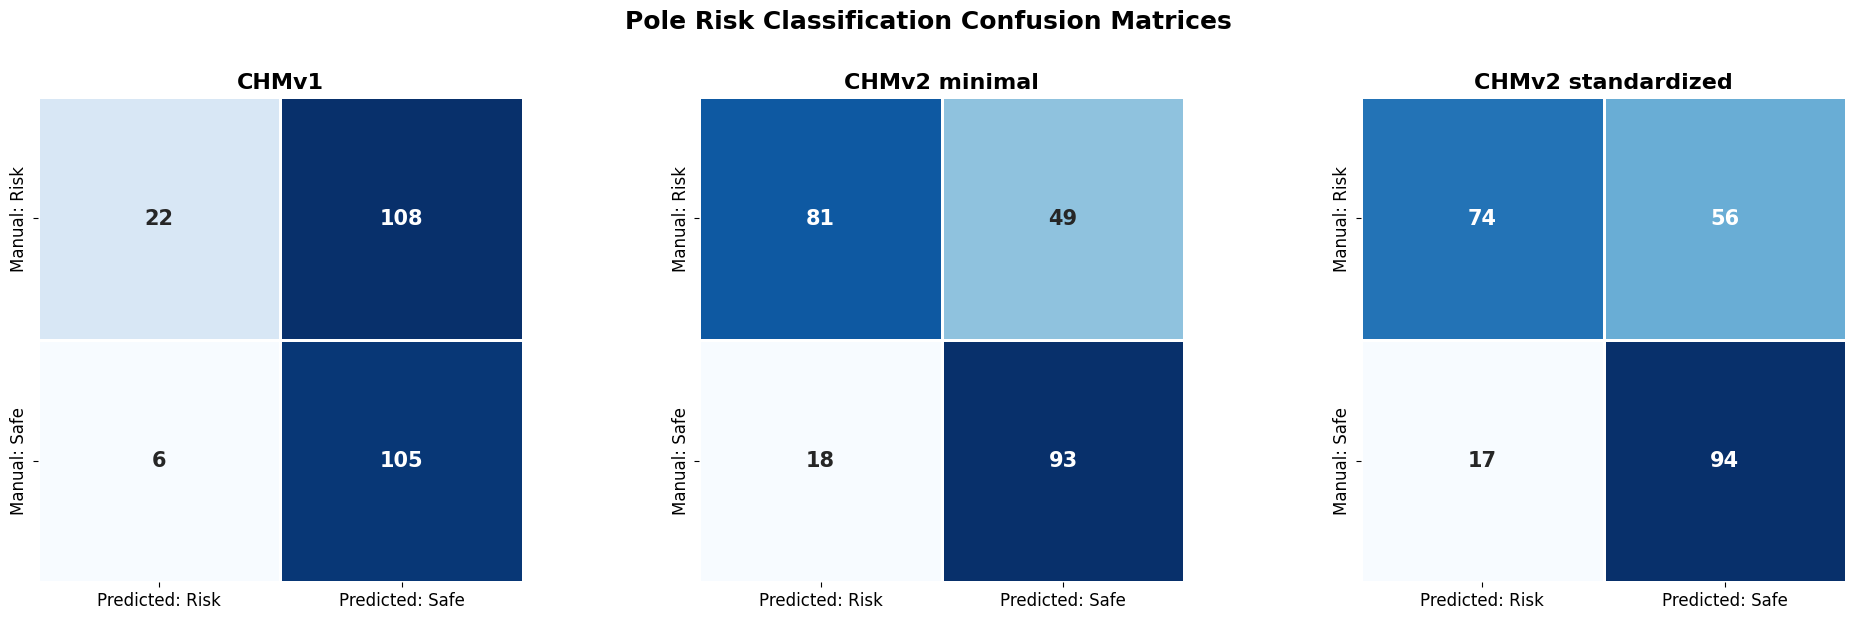

In [27]:
def rename_cm_for_display(cm):
    cm_disp = cm.copy()
    cm_disp.index = ["Manual: Risk", "Manual: Safe"]
    cm_disp.columns = ["Predicted: Risk", "Predicted: Safe"]
    return cm_disp

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

items = [
    ("CHMv1", rename_cm_for_display(cm_chmv1)),
    ("CHMv2 minimal", rename_cm_for_display(cm_chmv2_min)),
    ("CHMv2 standardized", rename_cm_for_display(cm_chmv2_std)),
]

for ax, (title, cm) in zip(axes, items):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        linewidths=1,
        linecolor="white",
        annot_kws={"size": 15, "weight": "bold"},
        ax=ax
    )
    ax.set_title(title, fontsize=16, weight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='both', labelsize=12)

plt.suptitle("Pole Risk Classification Confusion Matrices", fontsize=18, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


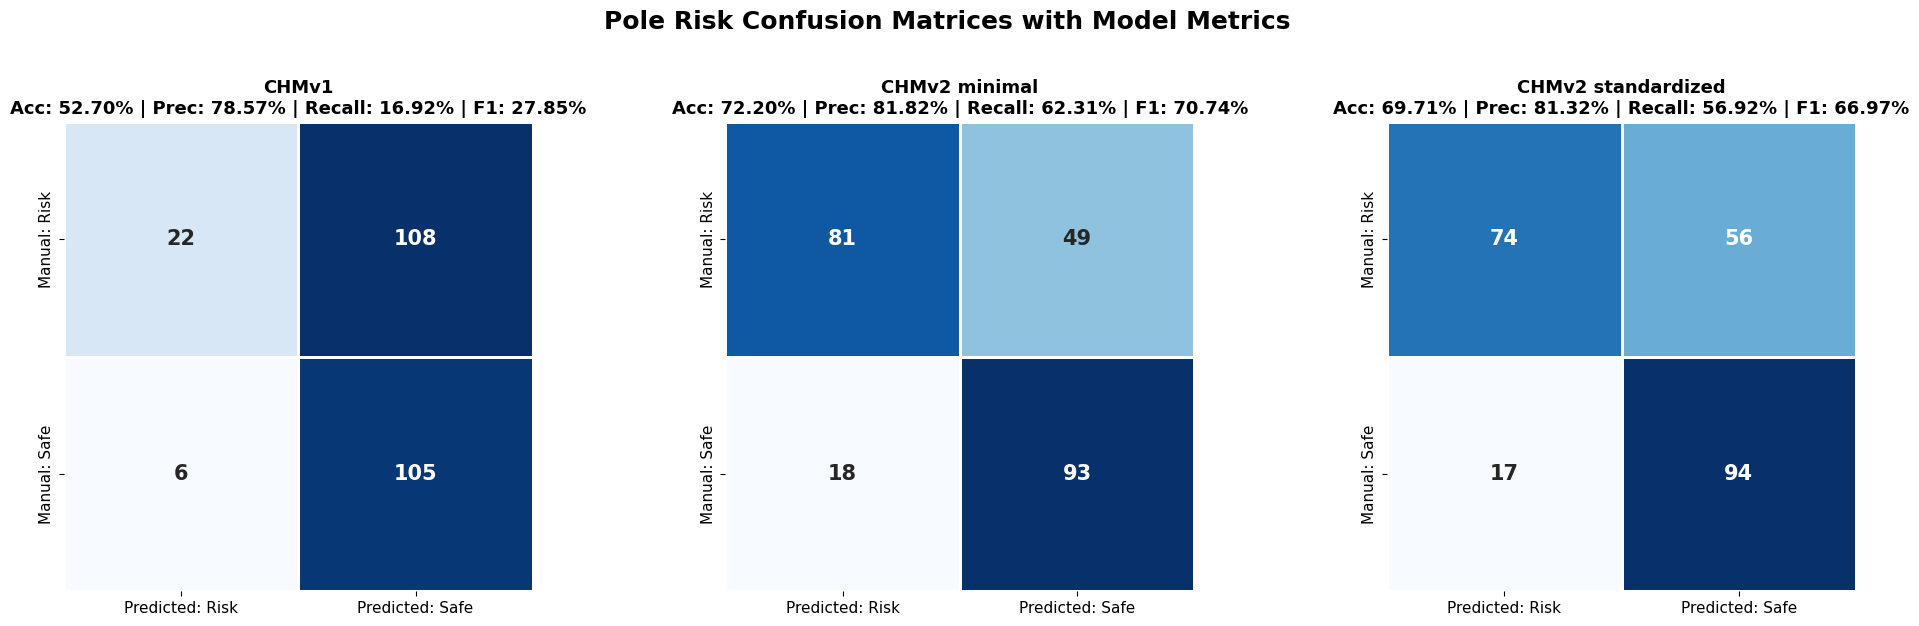

In [28]:
metrics_lookup = metrics_pct.set_index("model")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

items = [
    ("CHMv1", rename_cm_for_display(cm_chmv1)),
    ("CHMv2 minimal", rename_cm_for_display(cm_chmv2_min)),
    ("CHMv2 standardized", rename_cm_for_display(cm_chmv2_std)),
]

for ax, (title, cm) in zip(axes, items):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        linewidths=1,
        linecolor="white",
        annot_kws={"size": 15, "weight": "bold"},
        ax=ax
    )

    acc = metrics_lookup.loc[title, "accuracy"]
    prec = metrics_lookup.loc[title, "precision"]
    rec = metrics_lookup.loc[title, "recall"]
    f1 = metrics_lookup.loc[title, "f1"]

    ax.set_title(
        f"{title}\nAcc: {acc:.2f}% | Prec: {prec:.2f}% | Recall: {rec:.2f}% | F1: {f1:.2f}%",
        fontsize=13,
        weight="bold"
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='both', labelsize=11)

plt.suptitle("Pole Risk Confusion Matrices with Model Metrics", fontsize=18, weight="bold", y=1.03)
plt.tight_layout()
plt.show()


In [29]:
output_csv = Path("/content/drive/MyDrive/electric-pole-analysis/outputs/pole_filtering/poles_inside_all_three_models_robust_rule_results.csv")
df.to_csv(output_csv, index=False)
print("Saved:", output_csv)


Saved: /content/drive/MyDrive/electric-pole-analysis/outputs/pole_filtering/poles_inside_all_three_models_robust_rule_results.csv
